In [ ]:
# Import Neural Network and all components
%run ./nn/nn.ipynb

Loading MNIST dataset...
Dataset loaded successfully!

Original Shapes:
X shape: (70000, 784)
y shape: (70000,)


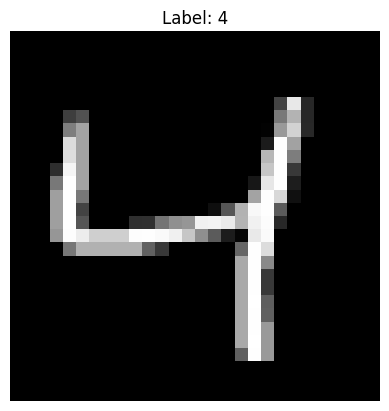


After normalization:
Min pixel value: 0.0
Max pixel value: 1.0

Train/Test Split:
X_train: (56000, 784)
X_test : (14000, 784)
y_train: (56000,)
y_test : (14000,)


In [ ]:
# STEP 1 + STEP 2
# Load MNIST, visualize image, flatten, normalize

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# STEP 1 — LOAD MNIST DATASET

print("Loading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1, n_retries=5, delay=2)

# Features (images)
X = mnist.data

# Labels (digits)
y = mnist.target.astype(int)

print("Dataset loaded successfully!")

# CHECK ORIGINAL SHAPES

print("\nOriginal Shapes:")
print("X shape:", X.shape)   # Expected: (70000, 784)
print("y shape:", y.shape)   # Expected: (70000,)

# STEP 2 — VISUALIZE ONE IMAGE

# Select first image
sample_image = X.iloc[2].values #iloc-> label based indexing

# Reshape back to 28x28 for visualization
sample_image_2d = sample_image.reshape(28, 28)

# Display image
plt.imshow(sample_image_2d, cmap='gray')
plt.title(f"Label: {y[2]}")
plt.axis('off')
plt.show()


# STEP 3 — NORMALIZATION

# Pixel values currently range from 0 to 255
# Normalize to range 0.0 to 1.0 to reduce biasing and overfitting

X = X / 255.0

print("\nAfter normalization:")
print("Min pixel value:", X.min().min())
print("Max pixel value:", X.max().max())

# STEP 4 — TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain/Test Split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# IMPORTANT UNDERSTANDING

# Each row in X_train:
# shape = (784,)

# Meaning:
# one flattened 28x28 image
# The neural network input layer must therefore contain 784 neurons.


#**FORWARD PASS:**

First pass example-

In [ ]:
# batch = np.random.randn(32,784)
# # Define the network architecture: input layer (784), hidden layer (128), output layer (10)
# model = NeuralNetwork(
#     layer_dims=[784, 128,64,32, 10],
#     activation_type='relu'
# )


# #forward pass
# logits = model._feed_forward(batch)
# func_instance = Function()
# prob=func_instance.softmax(logits)
# loss=crossentropy(prob,matrix)

#**TRAINING THE MODEL:**

Train class in which we are going to run the passes for the actual training of the model

In [ ]:
num_classes = len(np.unique(y_train))

# Initialize the model using X_train.shape[1] for input dimension
model = NeuralNetwork(
    layer_dims=[X_train.shape[1], 128, 64, 32, num_classes], # num_classes for the output layer
    activation_type='relu'
)

# Define training parameters
epochs = 5
batch_size = 32
learning_rate = 0.01

print(f"Starting training with {epochs} epochs, batch size {batch_size}, learning rate {learning_rate}")
print(f"Number of classes detected: {num_classes}")

# Call the fit method
model.fit(
    x=X_train,
    y=y_train,
    epochs=epochs,
    learning_rate=learning_rate,
    batch_size=batch_size,
    dataset=None, # Matches the 'dataset' parameter in your fit method's signature
    num_classes=num_classes
)

print("\nTraining complete.")

Starting training with 5 epochs, batch size 32, learning rate 0.01
Number of classes detected: 10

Epoch 1/5 :


100%|██████████| 1750/1750 [00:05<00:00, 318.25it/s]


Loss: 2.3018

Epoch 2/5 :


100%|██████████| 1750/1750 [00:07<00:00, 226.70it/s]


Loss: 2.3013

Epoch 3/5 :


...

Loss: 2.3013

Epoch 4/5 :


100%|██████████| 1750/1750 [00:05<00:00, 324.12it/s]


Loss: 2.3013

Epoch 5/5 :


100%|██████████| 1750/1750 [00:07<00:00, 222.06it/s]

Loss: 2.3013

Training complete.
